# Insurance Anti-Fraud Detection: phân tích & mô hình phân loại

**Mục tiêu:** dự đoán hồ sơ bồi thường bảo hiểm xe có gian lận hay không (`fraud_reported` = Y/N).

**Nguồn dữ liệu:** repo GitHub `Eliza516/Insurance-Anti-Fraud-Detection`, file `insurance_claims.csv`, commit `7d1b322792ba45878c0f1a879e6aee8328939d34` (dữ liệu gốc từ Kaggle *Insurance Fraud Claims Detection*, buntyshah).

**Yêu cầu từ README:** KNN, Logistic Regression, Naive Bayes, Decision Tree, Random Forest; chia train/test 8/2; vẽ cây quyết định; tìm 5 feature quan trọng nhất; có thể dùng feature selection.

**Giả định:**
- Bài toán phân loại nhị phân, lớp dương = gian lận (Y).
- Lớp gian lận là lớp thiểu số (~25%), nên metric chính là **PR-AUC (average precision)**; ROC-AUC, F1, precision và recall được báo cáo kèm.
- Mỗi dòng là một hợp đồng riêng biệt (`policy_number` duy nhất), nên không cần chia theo nhóm.
- Ngày sự cố chỉ trải trong 2 tháng (01–03/2015), bài toán không phải dự báo tương lai, nên dùng chia ngẫu nhiên có stratify.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from IPython.display import display
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score,
                             recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay, classification_report)

SEED = 42
np.random.seed(SEED)
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## 1. Load dữ liệu

In [2]:
# keep_default_na=False: giá trị 'None' ở authorities_contacted là một hạng mục thật
# ("không liên hệ cơ quan nào"), không phải missing.
LOCAL = '../insurance_claims.csv'
URL = 'https://raw.githubusercontent.com/Eliza516/Insurance-Anti-Fraud-Detection/7d1b322792ba45878c0f1a879e6aee8328939d34/insurance_claims.csv'
df_raw = pd.read_csv(LOCAL if os.path.exists(LOCAL) else URL, keep_default_na=False, na_values=[''])
print(df_raw.shape)
df_raw.head()

(1000, 40)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,None,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## 2. Profiling nhanh (chỉ quan sát, chưa biến đổi)

In [3]:
profile = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_missing': df_raw.isna().sum(),
    'n_question_mark': (df_raw.astype(str) == '?').sum(),
    'n_unique': df_raw.nunique(),
})
print('Dòng trùng lặp:', df_raw.duplicated().sum())
print('policy_number duy nhất:', df_raw['policy_number'].is_unique)
print('Khoảng ngày sự cố:', df_raw['incident_date'].min(), '->', df_raw['incident_date'].max())
profile

Dòng trùng lặp: 0
policy_number duy nhất: True
Khoảng ngày sự cố: 2015-01-01 -> 2015-03-01


,dtype,n_missing,n_question_mark,n_unique
months_as_customer,int64,0,0,391
age,int64,0,0,46
policy_number,int64,0,0,1000
policy_bind_date,str,0,0,951
policy_state,str,0,0,3
policy_csl,str,0,0,3
policy_deductable,int64,0,0,3
policy_annual_premium,float64,0,0,991
umbrella_limit,int64,0,0,11
insured_zip,int64,0,0,995


In [4]:
print(df_raw['fraud_reported'].value_counts())
print((df_raw['fraud_reported'].value_counts(normalize=True) * 100).round(1))

fraud_reported
N    753
Y    247
Name: count, dtype: int64
fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64


**Quan sát:**
- 1.000 dòng, không trùng lặp, mỗi `policy_number` là duy nhất. Không có nhóm lặp lại nên chia ngẫu nhiên là hợp lệ.
- `_c39` rỗng hoàn toàn nên bỏ đi.
- Missing thực tế được mã hóa bằng `?` ở 3 cột: `collision_type` (178), `property_damage` (360), `police_report_available` (343).
- `policy_number`, `incident_location`, `insured_zip` gần như duy nhất cho từng dòng. Đây là định danh, không có giá trị dự đoán tổng quát (và `incident_location`, `insured_zip` mang tính PII), nên loại bỏ.
- Nhãn mất cân bằng: 75,3% N và 24,7% Y, nên cần chia có stratify và dùng `class_weight`.

## 3. Chia train / test (80/20, stratify)

Dữ liệu có < 2.000 dòng và README yêu cầu tỉ lệ 8/2, nên dùng **80% train / 20% test** và **5-fold Stratified CV trên train** để chọn mô hình và tham số. Tập test chỉ dùng ở bước đánh giá cuối.

In [5]:
df = df_raw.copy()
y_all = (df['fraud_reported'] == 'Y').astype(int)
X_all = df.drop(columns=['fraud_reported'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)

split_summary = pd.DataFrame({
    'n_rows': [len(y_train), len(y_test)],
    'share_%': [len(y_train) / len(y_all) * 100, len(y_test) / len(y_all) * 100],
    'fraud_rate_%': [y_train.mean() * 100, y_test.mean() * 100],
}, index=['train', 'test']).round(1)
assert set(X_train_raw['policy_number']).isdisjoint(set(X_test_raw['policy_number']))
print('OK: không trùng policy_number giữa train và test')
split_summary

OK: không trùng policy_number giữa train và test


,n_rows,share_%,fraud_rate_%
train,800,80.0,24.8
test,200,20.0,24.5


In [6]:
# Kiểm tra phân phối feature số giữa train và test (KS test)
num_check = ['months_as_customer', 'age', 'policy_annual_premium', 'total_claim_amount',
             'injury_claim', 'property_claim', 'vehicle_claim', 'incident_hour_of_the_day']
ks = pd.DataFrame([(c, *stats.ks_2samp(X_train_raw[c], X_test_raw[c])) for c in num_check],
                  columns=['feature', 'KS_stat', 'p_value']).round(3)
ks

,feature,KS_stat,p_value
0,months_as_customer,0.049,0.831
1,age,0.060,0.600
2,policy_annual_premium,0.080,0.250
3,total_claim_amount,0.094,0.116
4,injury_claim,0.080,0.250
5,property_claim,0.095,0.107
6,vehicle_claim,0.084,0.205
7,incident_hour_of_the_day,0.060,0.600


Quan sát: không có p-value nào < 0,05, tức train và test có phân phối tương đồng. Đây là kỳ vọng tự nhiên của chia ngẫu nhiên, nên không cần adversarial validation.

## 4. Làm sạch (quy tắc cấu trúc, không học từ dữ liệu)

Các bước dưới đây là biến đổi xác định (không fit tham số), nên áp dụng giống nhau cho train và test:
- Bỏ cột rỗng `_c39` và các cột định danh/PII (`policy_number`, `insured_zip`, `incident_location`).
- `?` được thay bằng hạng mục `'Unknown'`. Việc thiếu thông tin (ví dụ không rõ có biên bản công an không) có thể tự nó mang tín hiệu, nên giữ lại làm một hạng mục thay vì điền mode.
- Từ hai cột ngày, tạo `policy_age_days` (số ngày từ lúc ký hợp đồng tới sự cố) và `incident_weekday`, rồi bỏ cột ngày gốc.
- Tạo đặc trưng tỉ lệ `injury_share`, `property_share`, `vehicle_share` (phần của từng loại trong tổng bồi thường).
- `auto_year` được đổi thành `vehicle_age` = 2015 − năm sản xuất.

In [7]:
DROP_COLS = ['_c39', 'policy_number', 'insured_zip', 'incident_location']

def clean(X: pd.DataFrame) -> pd.DataFrame:
    X = X.drop(columns=DROP_COLS).copy()
    X = X.replace('?', 'Unknown')
    bind = pd.to_datetime(X.pop('policy_bind_date'))
    inc = pd.to_datetime(X.pop('incident_date'))
    X['policy_age_days'] = (inc - bind).dt.days
    X['incident_weekday'] = inc.dt.day_name()
    total = X['total_claim_amount'].replace(0, np.nan)
    for c in ['injury', 'property', 'vehicle']:
        X[f'{c}_share'] = (X[f'{c}_claim'] / total).fillna(0)
    X['vehicle_age'] = 2015 - X.pop('auto_year')
    return X

X_train = clean(X_train_raw)
X_test = clean(X_test_raw)
print('train:', X_train_raw.shape, '->', X_train.shape, '| test:', X_test_raw.shape, '->', X_test.shape)

cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print(len(num_cols), 'cột số:', num_cols)
print(len(cat_cols), 'cột phân loại:', cat_cols)

train: (800, 39) -> (800, 38) | test: (200, 39) -> (200, 38)
20 cột số: ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'policy_age_days', 'injury_share', 'property_share', 'vehicle_share', 'vehicle_age']
18 cột phân loại: ['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model', 'incident_weekday']


## 5. EDA (chỉ trên train)

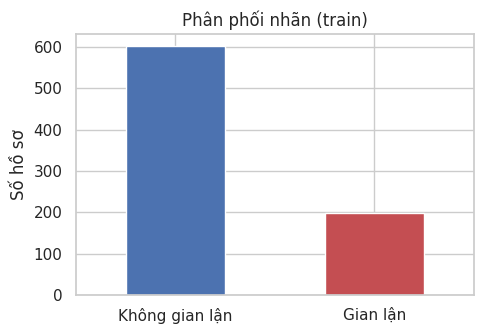

In [8]:
eda = X_train.assign(fraud=y_train.values)
fig, ax = plt.subplots(figsize=(5, 3.5))
eda['fraud'].map({0: 'Không gian lận', 1: 'Gian lận'}).value_counts().plot.bar(ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Phân phối nhãn (train)'); ax.set_ylabel('Số hồ sơ'); ax.set_xlabel('')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig('figures/01_target.png', dpi=120); plt.show()

Quan sát: khoảng 1/4 hồ sơ bị đánh dấu gian lận, nên accuracy dễ gây ảo tưởng (đoán toàn \"không gian lận\" vẫn đạt ~75%).

In [9]:
# Tỉ lệ gian lận theo từng biến phân loại: xếp theo độ chênh lệch (max - min) giữa các hạng mục
spread = {}
for c in cat_cols:
    g = eda.groupby(c)['fraud'].agg(['mean', 'size'])
    g = g[g['size'] >= 15]
    spread[c] = g['mean'].max() - g['mean'].min()
spread = pd.Series(spread).sort_values(ascending=False)
spread.round(3).to_frame('fraud_rate_spread')

,fraud_rate_spread
insured_hobbies,0.800
incident_severity,0.518
auto_model,0.492
incident_state,0.339
authorities_contacted,0.235
insured_occupation,0.205
incident_type,0.203
auto_make,0.202
collision_type,0.199
incident_weekday,0.142


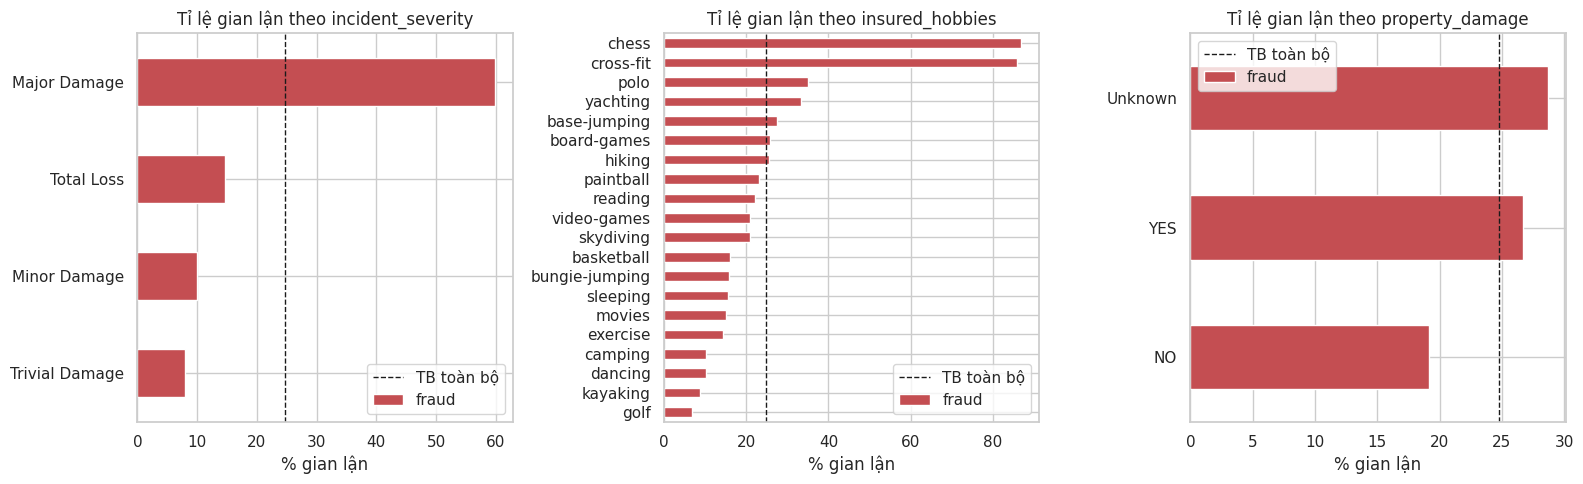

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, c in zip(axes, ['incident_severity', 'insured_hobbies', 'property_damage']):
    r = eda.groupby(c)['fraud'].mean().sort_values() * 100
    r.plot.barh(ax=ax, color='#C44E52')
    ax.axvline(eda['fraud'].mean() * 100, ls='--', c='k', lw=1, label='TB toàn bộ')
    ax.set_title(f'Tỉ lệ gian lận theo {c}'); ax.set_xlabel('% gian lận'); ax.set_ylabel(''); ax.legend()
plt.tight_layout(); plt.savefig('figures/02_fraud_by_category.png', dpi=120); plt.show()

**Quan sát:**
- `incident_severity = Major Damage` có tỉ lệ gian lận cao vượt trội (~60%), trong khi các mức còn lại chỉ khoảng 10%.
- Sở thích `chess` và `cross-fit` có tỉ lệ gian lận rất cao. Đây là tín hiệu mạnh, nhưng có thể là đặc thù của bộ dữ liệu (nhiều khả năng là dữ liệu mô phỏng), nên cần thận trọng khi tổng quát hóa.
- `property_damage` và `police_report_available` chênh lệch ít hơn nhiều.

In [11]:
# Chi-square test cho 2 biến phân loại nổi bật nhất (trên train)
rows = []
for c in ['incident_severity', 'insured_hobbies', 'police_report_available', 'insured_sex']:
    ct = pd.crosstab(eda[c], eda['fraud'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    rows.append((c, round(chi2, 1), dof, p, round(cramers_v, 3)))
pd.DataFrame(rows, columns=['feature', 'chi2', 'dof', 'p_value', 'cramers_V'])

,feature,chi2,dof,p_value,cramers_V
0,incident_severity,201.2,3,2.362575e-43,0.501
1,insured_hobbies,171.1,19,1.746357e-26,0.462
2,police_report_available,1.5,2,4.773624e-01,0.043
3,insured_sex,0.0,1,1.000000e+00,0.000


H0: biến độc lập với nhãn gian lận. `incident_severity` và `insured_hobbies` có p rất nhỏ và Cramér's V ở mức trung bình–lớn, tức liên hệ thực chất. `police_report_available` và `insured_sex` không có bằng chứng liên hệ. Đây là 4 kiểm định nên nếu hiệu chỉnh Bonferroni (α = 0,0125) thì kết luận không đổi.

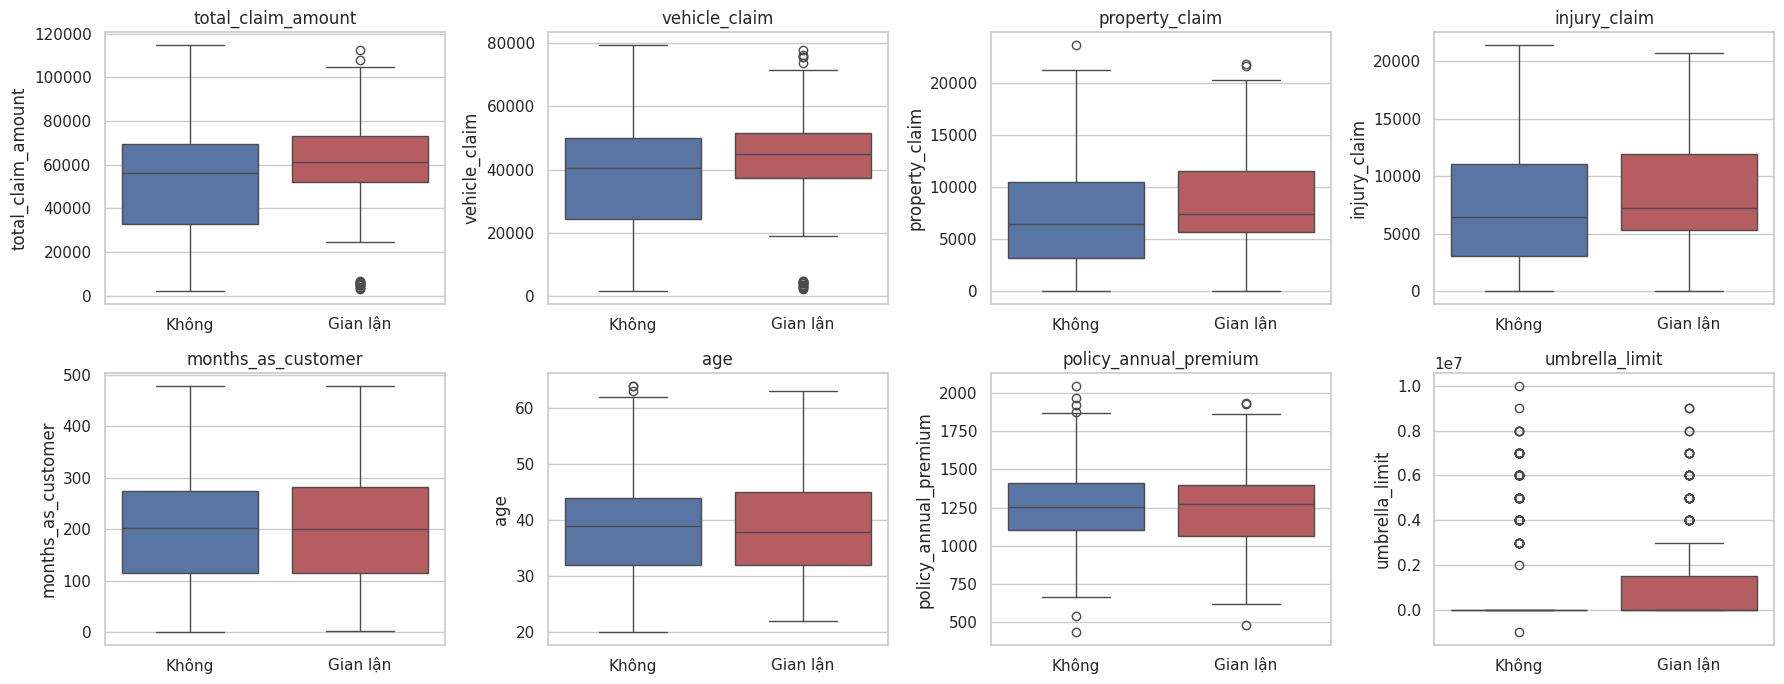

,feature,median_fraud,median_nonfraud,p_mannwhitney
0,total_claim_amount,60995.00,56080.000,0.0000
1,vehicle_claim,44800.00,40560.000,0.0000
2,property_claim,7430.00,6440.000,0.0001
3,injury_claim,7225.00,6505.000,0.0087
4,months_as_customer,200.50,203.000,0.6382
5,age,38.00,39.000,0.9018
6,policy_annual_premium,1276.32,1255.515,0.9422
7,umbrella_limit,0.00,0.000,0.0384


In [12]:
num_eda = ['total_claim_amount', 'vehicle_claim', 'property_claim', 'injury_claim',
           'months_as_customer', 'age', 'policy_annual_premium', 'umbrella_limit']
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, c in zip(axes.ravel(), num_eda):
    sns.boxplot(data=eda, x='fraud', y=c, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_xticklabels(['Không', 'Gian lận']); ax.set_xlabel(''); ax.set_title(c)
plt.tight_layout(); plt.savefig('figures/03_numeric_boxplots.png', dpi=120); plt.show()

mw = pd.DataFrame([(c, eda.loc[eda.fraud == 1, c].median(), eda.loc[eda.fraud == 0, c].median(),
                    stats.mannwhitneyu(eda.loc[eda.fraud == 1, c], eda.loc[eda.fraud == 0, c]).pvalue)
                   for c in num_eda], columns=['feature', 'median_fraud', 'median_nonfraud', 'p_mannwhitney'])
mw.round(4)

Quan sát: hồ sơ gian lận có tổng tiền bồi thường cao hơn (chủ yếu do `vehicle_claim` và `property_claim`). Các biến nhân khẩu học và hợp đồng (tuổi, thâm niên, phí) gần như không khác biệt.

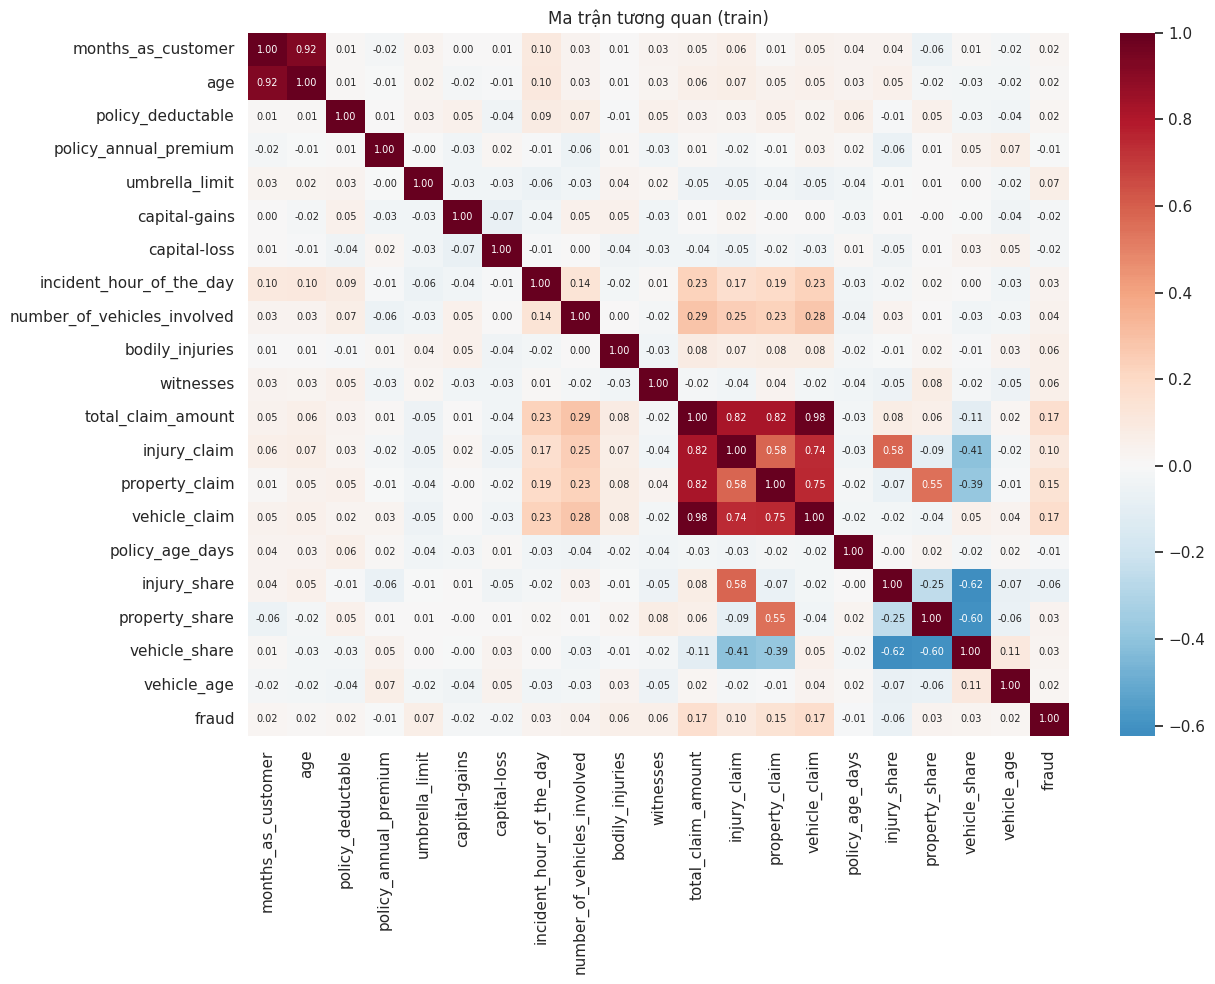

In [13]:
corr = eda[num_cols + ['fraud']].corr()
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', annot_kws={'size': 7}, ax=ax)
ax.set_title('Ma trận tương quan (train)')
plt.tight_layout(); plt.savefig('figures/04_corr.png', dpi=120); plt.show()

**Quan sát:**
- `age` và `months_as_customer` tương quan rất cao (~0,92).
- `total_claim_amount` gần như bằng tổng ba loại claim nên tương quan cao với từng loại.
- Đa cộng tuyến ảnh hưởng tới việc diễn giải hệ số Logistic Regression, nhưng ít ảnh hưởng tới khả năng dự đoán. Feature selection và regularization sẽ giúp hạn chế.
- Tương quan tuyến tính giữa các biến số và nhãn đều yếu (< 0,2), nên tín hiệu chính nằm ở biến phân loại.

## 6. Feature engineering & Pipeline

- Tiền xử lý: `StandardScaler` cho biến số, `OneHotEncoder(handle_unknown='ignore')` cho biến phân loại.
- **Feature selection:** `SelectKBest(f_classif)`, với số feature `k` được tune bằng CV.
- Toàn bộ nằm trong `Pipeline`, nên mọi bước `fit` chỉ thấy phần train của từng fold (không rò rỉ).

In [14]:
def make_pipe(model, select=True, scale=True):
    # Mô hình cây không cần chuẩn hóa -> giữ nguyên đơn vị gốc (USD, tháng...) để dễ đọc ngưỡng
    pre = ColumnTransformer([
        ('num', StandardScaler() if scale else 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])
    steps = [('pre', pre)]
    if select:
        steps.append(('select', SelectKBest(f_classif)))
    steps.append(('model', model))
    return Pipeline(steps)

n_ohe = make_pipe(DummyClassifier(), select=False).named_steps['pre'].fit(X_train).transform(X_train).shape[1]
print('Số feature sau one-hot:', n_ohe)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {'pr_auc': 'average_precision', 'roc_auc': 'roc_auc', 'f1': 'f1'}
K_GRID = [5, 10, 20, 40, 'all']

Số feature sau one-hot: 172


## 7. Baseline → 5 mô hình → tuning bằng GridSearchCV (5-fold Stratified)

In [15]:
search_spaces = {
    'Dummy (baseline)': (make_pipe(DummyClassifier(strategy='stratified', random_state=SEED), select=False), {}),
    'Logistic Regression': (make_pipe(LogisticRegression(max_iter=2000, class_weight='balanced', solver='liblinear', random_state=SEED)),
                            {'select__k': K_GRID, 'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l1', 'l2']}),
    'KNN': (make_pipe(KNeighborsClassifier()),
            {'select__k': K_GRID, 'model__n_neighbors': [5, 11, 21, 31], 'model__weights': ['uniform', 'distance']}),
    'Naive Bayes': (make_pipe(GaussianNB()),
                    {'select__k': K_GRID, 'model__var_smoothing': [1e-9, 1e-6, 1e-3, 1e-1]}),
    'Decision Tree': (make_pipe(DecisionTreeClassifier(class_weight='balanced', random_state=SEED), scale=False),
                      {'select__k': K_GRID, 'model__max_depth': [2, 3, 4, 5, 8],
                       'model__min_samples_leaf': [1, 10, 20]}),
    'Random Forest': (make_pipe(RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=SEED), scale=False),
                      {'select__k': [10, 20, 40, 'all'], 'model__max_depth': [4, 8, None],
                       'model__min_samples_leaf': [1, 5], 'model__max_features': ['sqrt', 0.3]}),
}

searches, rows = {}, []
for name, (pipe, grid) in search_spaces.items():
    gs = GridSearchCV(pipe, grid, scoring=SCORING, refit='pr_auc', cv=cv, n_jobs=-1, return_train_score=True)
    gs.fit(X_train, y_train)
    searches[name] = gs
    r = gs.cv_results_; i = gs.best_index_
    rows.append({
        'model': name,
        'CV PR-AUC': f"{r['mean_test_pr_auc'][i]:.3f} ± {r['std_test_pr_auc'][i]:.3f}",
        'CV ROC-AUC': f"{r['mean_test_roc_auc'][i]:.3f} ± {r['std_test_roc_auc'][i]:.3f}",
        'CV F1': f"{r['mean_test_f1'][i]:.3f} ± {r['std_test_f1'][i]:.3f}",
        'train PR-AUC': round(r['mean_train_pr_auc'][i], 3),
        'cv_pr_auc_mean': r['mean_test_pr_auc'][i],
        'best_params': {k.split('__')[1]: v for k, v in gs.best_params_.items()},
    })
cv_table = pd.DataFrame(rows).sort_values('cv_pr_auc_mean', ascending=False).reset_index(drop=True)
cv_table.drop(columns='cv_pr_auc_mean')

,model,CV PR-AUC,CV ROC-AUC,CV F1,train PR-AUC,best_params
0,Naive Bayes,0.726 ± 0.022,0.888 ± 0.016,0.744 ± 0.022,0.726,"{'var_smoothing': 0.001, 'k': 10}"
1,Decision Tree,0.712 ± 0.056,0.885 ± 0.028,0.756 ± 0.032,0.792,"{'max_depth': 5, 'min_samples_leaf': 10, 'k': 10}"
2,Logistic Regression,0.707 ± 0.031,0.876 ± 0.034,0.756 ± 0.032,0.708,"{'C': 10, 'penalty': 'l2', 'k': 5}"
3,Random Forest,0.646 ± 0.032,0.855 ± 0.022,0.676 ± 0.039,1.000,"{'max_depth': None, 'max_features': 0.3, 'min_..."
4,KNN,0.628 ± 0.052,0.860 ± 0.034,0.671 ± 0.067,0.755,"{'n_neighbors': 5, 'weights': 'uniform', 'k': 5}"
5,Dummy (baseline),0.262 ± 0.046,0.500 ± 0.079,0.253 ± 0.119,0.253,{}


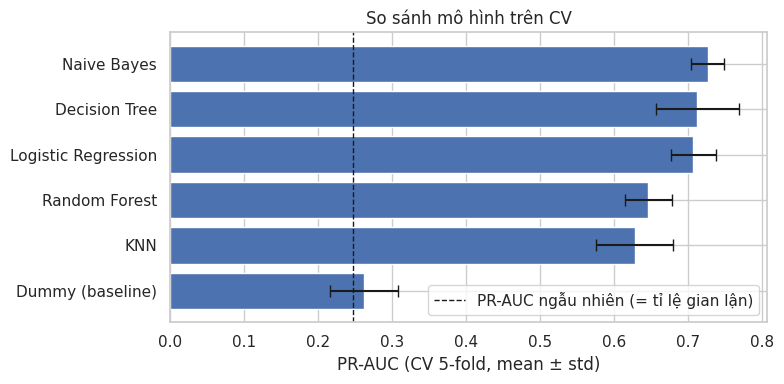

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
means = [searches[m].cv_results_['mean_test_pr_auc'][searches[m].best_index_] for m in cv_table['model']]
stds = [searches[m].cv_results_['std_test_pr_auc'][searches[m].best_index_] for m in cv_table['model']]
ax.barh(cv_table['model'][::-1], means[::-1], xerr=stds[::-1], color='#4C72B0', capsize=4)
ax.axvline(y_train.mean(), ls='--', c='k', lw=1, label='PR-AUC ngẫu nhiên (= tỉ lệ gian lận)')
ax.set_xlabel('PR-AUC (CV 5-fold, mean ± std)'); ax.set_title('So sánh mô hình trên CV'); ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('figures/05_cv_comparison.png', dpi=120); plt.show()

Quan sát: bảng và biểu đồ cho thấy mức chênh giữa các mô hình. Khoảng cách giữa train PR-AUC và CV PR-AUC là dấu hiệu overfit (xem thêm learning curve bên dưới).

In [17]:
# Ảnh hưởng của feature selection: điểm CV tốt nhất theo từng k (Logistic Regression & Decision Tree)
rows = []
for name in ['Logistic Regression', 'Decision Tree', 'Naive Bayes', 'KNN']:
    res = pd.DataFrame(searches[name].cv_results_)
    res['k'] = res['param_select__k'].astype(str)
    best_by_k = res.groupby('k')['mean_test_pr_auc'].max()
    for k, v in best_by_k.items():
        rows.append((name, k, v))
fs = pd.DataFrame(rows, columns=['model', 'k', 'best_cv_pr_auc']).pivot(index='k', columns='model', values='best_cv_pr_auc')
fs = fs.loc[[str(k) for k in K_GRID]]
fs.round(3)

model,Decision Tree,KNN,Logistic Regression,Naive Bayes
k,,,,
5,0.705,0.628,0.707,0.718
10,0.712,0.581,0.707,0.726
20,0.705,0.570,0.686,0.650
40,0.681,0.523,0.673,0.613
all,0.685,0.409,0.694,0.610


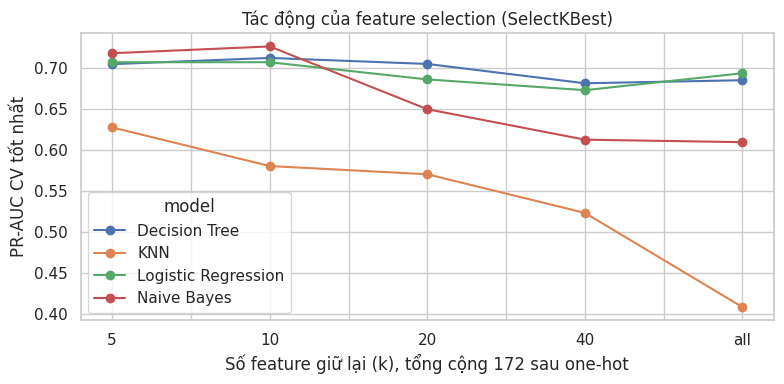

In [18]:
ax = fs.plot(marker='o', figsize=(8, 4))
ax.set_xlabel(f'Số feature giữ lại (k), tổng cộng {n_ohe} sau one-hot'); ax.set_ylabel('PR-AUC CV tốt nhất')
ax.set_title('Tác động của feature selection (SelectKBest)')
plt.tight_layout(); plt.savefig('figures/06_feature_selection.png', dpi=120); plt.show()

Quan sát: với hầu hết các mô hình, giữ một số ít feature (5–20) cho kết quả bằng hoặc tốt hơn dùng toàn bộ. Nghĩa là phần lớn feature là nhiễu, và giảm chiều giúp KNN/Naive Bayes đáng kể.

### 7.1 Chọn mô hình cuối & ngưỡng quyết định

Mô hình cuối được chọn theo CV PR-AUC cao nhất. Ngưỡng xác suất được chọn bằng **dự đoán out-of-fold trên train** (tối đa F1), hoàn toàn không dùng test.

In [19]:
best_name = cv_table.loc[0, 'model']
final_model = searches[best_name].best_estimator_
print('Mô hình cuối:', best_name, searches[best_name].best_params_)

oof = cross_val_predict(final_model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof)
f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
best_thr = float(thr[np.argmax(f1s)])
print(f'Ngưỡng tối ưu F1 (OOF train): {best_thr:.3f} | F1 OOF = {f1s.max():.3f} | F1 OOF tại 0.5 = {f1_score(y_train, oof >= 0.5):.3f}')

Mô hình cuối: Naive Bayes {'model__var_smoothing': 0.001, 'select__k': 10}
Ngưỡng tối ưu F1 (OOF train): 0.372 | F1 OOF = 0.755 | F1 OOF tại 0.5 = 0.743


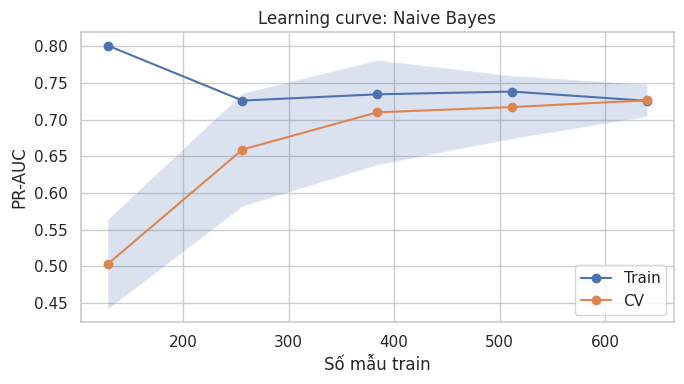

In [20]:
sizes, tr, va = learning_curve(final_model, X_train, y_train, cv=cv, scoring='average_precision',
                               train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, tr.mean(1), 'o-', label='Train'); ax.plot(sizes, va.mean(1), 'o-', label='CV')
ax.fill_between(sizes, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=0.2)
ax.set_xlabel('Số mẫu train'); ax.set_ylabel('PR-AUC'); ax.set_title(f'Learning curve: {best_name}'); ax.legend()
plt.tight_layout(); plt.savefig('figures/07_learning_curve.png', dpi=120); plt.show()

Quan sát: khoảng cách giữa hai đường cho biết mức overfit. Nếu đường CV còn tăng khi thêm mẫu thì có thêm dữ liệu sẽ giúp ích.

## 8. Đánh giá cuối trên tập test (chỉ một lần cho mô hình cuối)

In [21]:
def evaluate(y, p, thr):
    pred = (p >= thr).astype(int)
    return {'PR-AUC': average_precision_score(y, p), 'ROC-AUC': roc_auc_score(y, p),
            'F1': f1_score(y, pred), 'Precision': precision_score(y, pred, zero_division=0),
            'Recall': recall_score(y, pred), 'Accuracy': accuracy_score(y, pred)}

p_test = final_model.predict_proba(X_test)[:, 1]
p_base = searches['Dummy (baseline)'].best_estimator_.predict_proba(X_test)[:, 1]
final_eval = pd.DataFrame({
    f'{best_name} (ngưỡng {best_thr:.2f})': evaluate(y_test, p_test, best_thr),
    f'{best_name} (ngưỡng 0.50)': evaluate(y_test, p_test, 0.5),
    'Dummy baseline': evaluate(y_test, p_base, 0.5),
}).T.round(3)
final_eval

,PR-AUC,ROC-AUC,F1,Precision,Recall,Accuracy
Naive Bayes (ngưỡng 0.37),0.551,0.837,0.730,0.636,0.857,0.845
Naive Bayes (ngưỡng 0.50),0.551,0.837,0.737,0.646,0.857,0.850
Dummy baseline,0.260,0.534,0.300,0.294,0.306,0.650


In [22]:
cv_best = searches[best_name].cv_results_['mean_test_pr_auc'][searches[best_name].best_index_]
print(f'PR-AUC: CV = {cv_best:.3f} | Test = {average_precision_score(y_test, p_test):.3f} | chênh = {average_precision_score(y_test, p_test) - cv_best:+.3f}')
print(classification_report(y_test, (p_test >= best_thr).astype(int), target_names=['Không gian lận', 'Gian lận']))

PR-AUC: CV = 0.726 | Test = 0.551 | chênh = -0.176
                precision    recall  f1-score   support

Không gian lận       0.95      0.84      0.89       151
      Gian lận       0.64      0.86      0.73        49

      accuracy                           0.84       200
     macro avg       0.79      0.85      0.81       200
  weighted avg       0.87      0.84      0.85       200



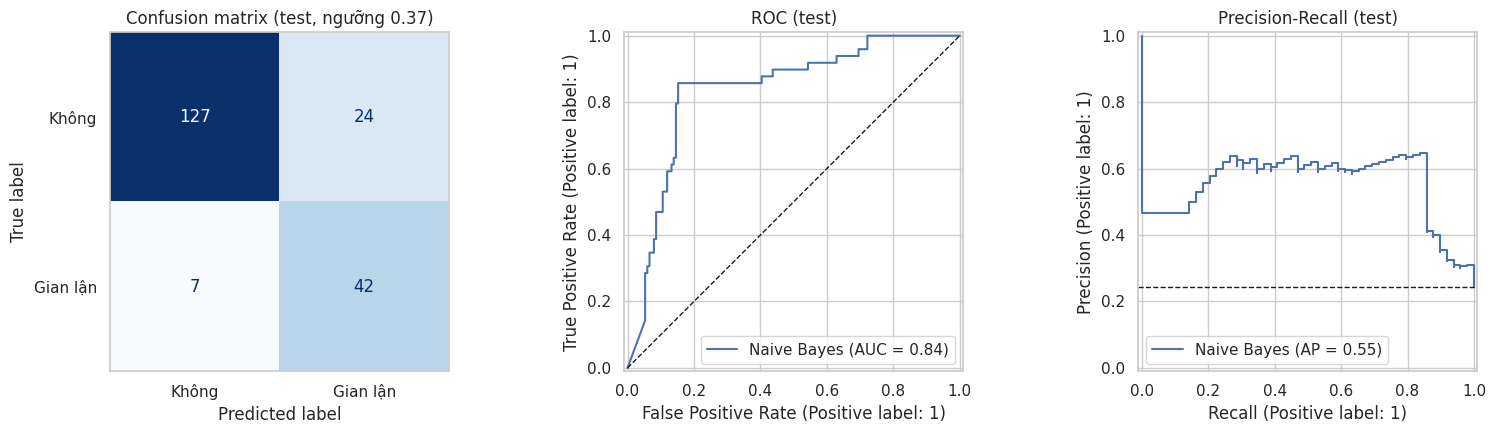

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, (p_test >= best_thr).astype(int)),
                       display_labels=['Không', 'Gian lận']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion matrix (test, ngưỡng {best_thr:.2f})'); axes[0].grid(False)
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[1], name=best_name)
axes[1].plot([0, 1], [0, 1], 'k--', lw=1); axes[1].set_title('ROC (test)')
PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[2], name=best_name)
axes[2].axhline(y_test.mean(), ls='--', c='k', lw=1); axes[2].set_title('Precision-Recall (test)')
plt.tight_layout(); plt.savefig('figures/08_test_eval.png', dpi=120); plt.show()

### 8.0 Độ bất định của điểm test & so sánh với quy tắc đơn giản

PR-AUC trên test thấp hơn CV khá nhiều. Test chỉ có 49 ca gian lận, nên cần đo độ bất định:
- **Bootstrap** khoảng tin cậy 95% cho điểm test.
- **Repeated CV** (5×5) trên train để xem PR-AUC dao động bao nhiêu giữa các cách chia.

In [24]:
rng = np.random.default_rng(SEED); boot = {'PR-AUC': [], 'F1': []}
yt = y_test.values; pred_t = (p_test >= best_thr).astype(int)
for _ in range(2000):
    i = rng.integers(0, len(yt), len(yt))
    if yt[i].sum() == 0: continue
    boot['PR-AUC'].append(average_precision_score(yt[i], p_test[i]))
    boot['F1'].append(f1_score(yt[i], pred_t[i]))
ci = {k: np.percentile(v, [2.5, 97.5]).round(3) for k, v in boot.items()}
print('Bootstrap 95% CI trên test:', ci)

from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
rep = cross_val_score(final_model, X_train, y_train, scoring='average_precision', n_jobs=-1,
                      cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED))
print(f'Repeated CV 5x5 PR-AUC: {rep.mean():.3f} ± {rep.std():.3f} (min {rep.min():.3f}, max {rep.max():.3f})')
print(f'F1: OOF train = {f1s.max():.3f} | test = {f1_score(y_test, pred_t):.3f}')

Bootstrap 95% CI trên test: {'PR-AUC': array([0.427, 0.699]), 'F1': array([0.633, 0.811])}


Repeated CV 5x5 PR-AUC: 0.720 ± 0.048 (min 0.634, max 0.850)
F1: OOF train = 0.755 | test = 0.730


**Quy tắc 2 điều kiện rút ra từ EDA trên train:** gắn cờ gian lận nếu `incident_severity == 'Major Damage'` **hoặc** `insured_hobbies ∈ {chess, cross-fit}`. Quy tắc này dùng để kiểm tra xem mô hình học được gì hơn so với hai tín hiệu nổi bật nhất.

In [25]:
def rule(X):
    return ((X['incident_severity'] == 'Major Damage') | X['insured_hobbies'].isin(['chess', 'cross-fit'])).astype(int)
rule_tbl = pd.DataFrame({
    'Quy tắc 2 điều kiện (train)': {'F1': f1_score(y_train, rule(X_train)), 'Precision': precision_score(y_train, rule(X_train)), 'Recall': recall_score(y_train, rule(X_train))},
    'Quy tắc 2 điều kiện (test)': {'F1': f1_score(y_test, rule(X_test)), 'Precision': precision_score(y_test, rule(X_test)), 'Recall': recall_score(y_test, rule(X_test))},
    f'{best_name} (test)': {'F1': f1_score(y_test, pred_t), 'Precision': precision_score(y_test, pred_t), 'Recall': recall_score(y_test, pred_t)},
}).T.round(3)
print('Tỉ lệ dự đoán trùng giữa mô hình và quy tắc (test):', (pred_t == rule(X_test).values).mean())
display(rule_tbl)
display(pd.crosstab([X_train['incident_severity'] == 'Major Damage', X_train['insured_hobbies'].isin(['chess', 'cross-fit'])],
                    y_train.rename('fraud'), margins=True).rename_axis(['Major Damage', 'chess/cross-fit']))

Tỉ lệ dự đoán trùng giữa mô hình và quy tắc (test): 1.0


,F1,Precision,Recall
Quy tắc 2 điều kiện (train),0.755,0.653,0.894
Quy tắc 2 điều kiện (test),0.730,0.636,0.857
Naive Bayes (test),0.730,0.636,0.857


fraud                           0    1  All
Major Damage chess/cross-fit               
False        False            508   21  529
             True               6   46   52
True         False             85  120  205
             True               3   11   14
All                           602  198  800

**Quan sát:**
- Ở ngưỡng quyết định, mô hình cho kết quả gần như trùng với quy tắc 2 điều kiện. Tín hiệu gian lận của bộ dữ liệu tập trung gần như hoàn toàn vào hai biến này.
- Phần chênh PR-AUC giữa CV và test đến từ việc **xếp hạng bên trong** nhóm bị gắn cờ, vốn dựa trên số tiền bồi thường (tín hiệu yếu). Với chỉ 49 ca dương, thứ hạng này dao động lớn.
- F1 tại ngưỡng lại ổn định giữa CV và test.

### 8.1 Tham khảo: tất cả mô hình trên test

*Bảng này **không** được dùng để chọn mô hình (việc chọn đã chốt ở bước CV). Nó chỉ được đưa vào vì đề bài yêu cầu so sánh 5 mô hình. Mỗi mô hình dùng ngưỡng 0,5 mặc định.*

In [26]:
ref_rows = {}
for name, gs in searches.items():
    p = gs.best_estimator_.predict_proba(X_test)[:, 1]
    ref_rows[name] = evaluate(y_test, p, 0.5)
ref_test = pd.DataFrame(ref_rows).T.round(3).sort_values('PR-AUC', ascending=False)
ref_test

,PR-AUC,ROC-AUC,F1,Precision,Recall,Accuracy
KNN,0.609,0.843,0.598,0.604,0.592,0.805
Decision Tree,0.587,0.840,0.709,0.639,0.796,0.840
Random Forest,0.556,0.832,0.619,0.625,0.612,0.815
Naive Bayes,0.551,0.837,0.737,0.646,0.857,0.850
Logistic Regression,0.535,0.822,0.730,0.636,0.857,0.845
Dummy (baseline),0.260,0.534,0.300,0.294,0.306,0.650


## 9. Diễn giải mô hình

### 9.1 Visualize cây quyết định (mô hình Decision Tree đã tune)

Tham số: {'model__max_depth': 5, 'model__min_samples_leaf': 10, 'select__k': 10} | độ sâu thực tế: 5 | số lá: 16


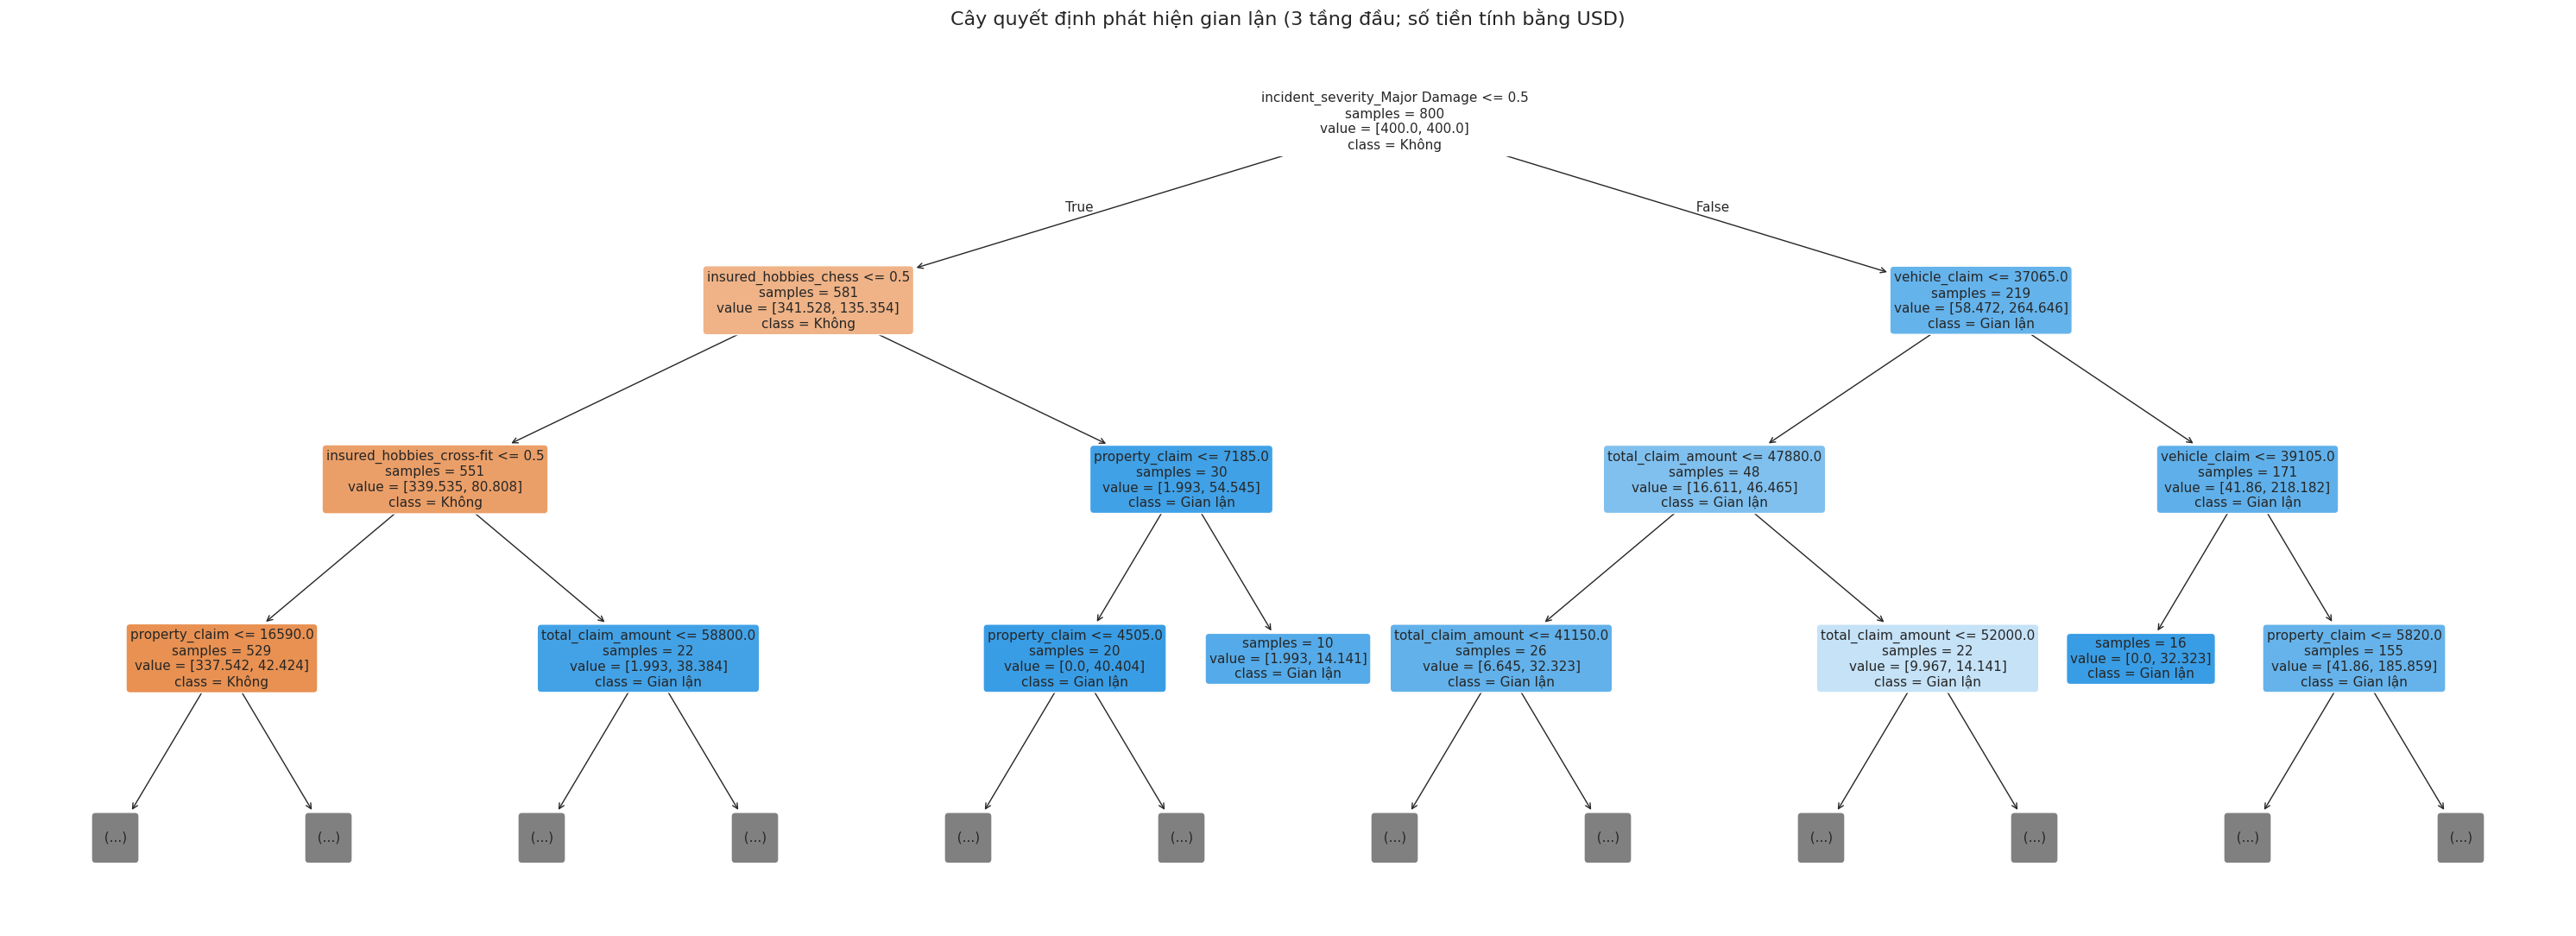

|--- incident_severity_Major Damage <= 0.50
|   |--- insured_hobbies_chess <= 0.50
|   |   |--- insured_hobbies_cross-fit <= 0.50
|   |   |   |--- property_claim <= 16590.00
|   |   |   |   |--- total_claim_amount <= 6140.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- total_claim_amount >  6140.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- property_claim >  16590.00
|   |   |   |   |--- class: 0
|   |   |--- insured_hobbies_cross-fit >  0.50
|   |   |   |--- total_claim_amount <= 58800.00
|   |   |   |   |--- class: 1
|   |   |   |--- total_claim_amount >  58800.00
|   |   |   |   |--- class: 1
|   |--- insured_hobbies_chess >  0.50
|   |   |--- property_claim <= 7185.00
|   |   |   |--- property_claim <= 4505.00
|   |   |   |   |--- class: 1
|   |   |   |--- property_claim >  4505.00
|   |   |   |   |--- class: 1
|   |   |--- property_claim >  7185.00
|   |   |   |--- class: 1
|--- incident_severity_Major Damage >  0.50
|   |--- vehicle_claim <= 37065.00
|   |   |--

In [27]:
dt_pipe = searches['Decision Tree'].best_estimator_
feat_after_pre = dt_pipe.named_steps['pre'].get_feature_names_out()
feat_dt = feat_after_pre[dt_pipe.named_steps['select'].get_support()]
feat_dt = [f.split('__', 1)[1] for f in feat_dt]
tree = dt_pipe.named_steps['model']
print('Tham số:', searches['Decision Tree'].best_params_, '| độ sâu thực tế:', tree.get_depth(), '| số lá:', tree.get_n_leaves())

fig, ax = plt.subplots(figsize=(30, 11))
plot_tree(tree, feature_names=feat_dt, class_names=['Không', 'Gian lận'], filled=True, rounded=True,
          impurity=False, proportion=False, fontsize=11, ax=ax, max_depth=3)
ax.set_title('Cây quyết định phát hiện gian lận (3 tầng đầu; số tiền tính bằng USD)', fontsize=16)
plt.tight_layout(); plt.savefig('figures/09_decision_tree.png', dpi=110); plt.show()
print(export_text(tree, feature_names=list(feat_dt), max_depth=4))

**Cách đọc:**
- Mỗi nút là một câu hỏi, và nhánh trái (True) nghĩa là điều kiện **đúng**.
- Với biến one-hot (ví dụ `incident_severity_Major Damage <= 0.5`), nhánh trái tương ứng với **không phải** Major Damage.
- Màu cam biểu thị nút nghiêng về "Không gian lận", màu xanh biểu thị nút nghiêng về "Gian lận".
- `value` là số mẫu **đã nhân trọng số** `class_weight='balanced'`, nên hai lớp được cân bằng ở nút gốc.

**Diễn giải:**
- Câu hỏi đầu tiên luôn là *thiệt hại có nghiêm trọng (Major Damage) không?*
- Nếu không, cây hỏi tiếp *người được bảo hiểm có sở thích chess hoặc cross-fit không?*
- Các tầng sâu hơn chỉ tách theo số tiền bồi thường, và phần lớn các lá con ở dưới vẫn cho cùng một kết luận.

### 9.2 Top 5 feature quan trọng nhất

In [28]:
# (a) Permutation importance trên TEST với mô hình cuối (hoán vị từng cột GỐC trước khi qua pipeline)
perm = permutation_importance(final_model, X_test, y_test, scoring='average_precision',
                              n_repeats=30, random_state=SEED, n_jobs=-1)
perm_df = pd.DataFrame({'feature': X_test.columns, 'importance_mean': perm.importances_mean,
                        'importance_std': perm.importances_std}).sort_values('importance_mean', ascending=False)
perm_df.head(10).round(4)

,feature,importance_mean,importance_std
16,incident_severity,0.2143,0.0174
10,insured_hobbies,0.1248,0.0279
17,authorities_contacted,0.0111,0.0131
28,property_claim,0.0048,0.0143
15,collision_type,0.0041,0.0094
0,months_as_customer,0.0000,0.0000
5,policy_annual_premium,0.0000,0.0000
4,policy_deductable,0.0000,0.0000
3,policy_csl,0.0000,0.0000
2,policy_state,0.0000,0.0000


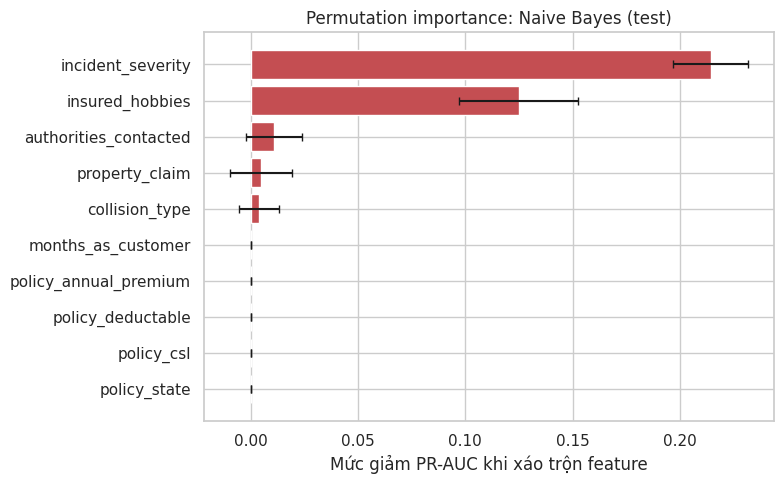

In [29]:
top = perm_df.head(10)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], color='#C44E52', capsize=3)
ax.set_xlabel('Mức giảm PR-AUC khi xáo trộn feature'); ax.set_title(f'Permutation importance: {best_name} (test)')
plt.tight_layout(); plt.savefig('figures/10_permutation_importance.png', dpi=120); plt.show()

In [30]:
# (b) Đối chiếu: importance nội tại của Random Forest và Decision Tree, gộp one-hot về cột gốc
def grouped_importance(pipe, values):
    names = pipe.named_steps['pre'].get_feature_names_out()[pipe.named_steps['select'].get_support()]
    s = pd.Series(values, index=names)
    orig = {}
    for n in s.index:
        kind, rest = n.split('__', 1)
        base = rest if kind == 'num' else next(c for c in sorted(cat_cols, key=len, reverse=True) if rest.startswith(c + '_'))
        orig[n] = base
    return s.groupby(orig).sum().sort_values(ascending=False)

rf_pipe = searches['Random Forest'].best_estimator_
lr_pipe = searches['Logistic Regression'].best_estimator_
compare = pd.DataFrame({
    'Permutation (mô hình cuối)': perm_df.set_index('feature')['importance_mean'].rank(ascending=False),
    'RF impurity': grouped_importance(rf_pipe, rf_pipe.named_steps['model'].feature_importances_).rank(ascending=False),
    'DT impurity': grouped_importance(dt_pipe, tree.feature_importances_).rank(ascending=False),
    '|LR coef|': grouped_importance(lr_pipe, np.abs(lr_pipe.named_steps['model'].coef_[0])).rank(ascending=False),
})
compare = compare.sort_values('Permutation (mô hình cuối)').head(10)
compare

,Permutation (mô hình cuối),RF impurity,DT impurity,|LR coef|
incident_severity,1.0,1.0,2.0,2.0
insured_hobbies,2.0,2.0,1.0,1.0
authorities_contacted,3.0,25.0,6.5,NaN
property_claim,4.0,6.0,4.0,NaN
collision_type,5.0,26.0,6.5,NaN
bodily_injuries,21.0,35.0,NaN,NaN
auto_model,21.0,3.0,NaN,NaN
auto_make,21.0,10.0,NaN,NaN
capital-loss,21.0,20.0,NaN,NaN
incident_city,21.0,17.0,NaN,NaN


In [31]:
# Xếp hạng đồng thuận: trung bình thứ hạng qua 4 phương pháp (feature không được mô hình dùng thì xếp hạng cuối)
all_rank = pd.DataFrame({
    'Permutation (mô hình cuối)': perm_df.set_index('feature')['importance_mean'].where(lambda s: s > 0),
    'RF impurity': grouped_importance(rf_pipe, rf_pipe.named_steps['model'].feature_importances_),
    'DT impurity': grouped_importance(dt_pipe, tree.feature_importances_).where(lambda s: s > 0),
    '|LR coef|': grouped_importance(lr_pipe, np.abs(lr_pipe.named_steps['model'].coef_[0])).where(lambda s: s > 0),
}).reindex(X_train.columns)
worst = len(all_rank)
ranks = all_rank.rank(ascending=False).fillna(worst)
ranks['mean_rank'] = ranks.mean(axis=1)
ranks = ranks.sort_values('mean_rank')
TOP5 = ranks.head(5).index.tolist()
print('Top 5 feature (đồng thuận 4 phương pháp):', TOP5)
ranks.head(8).round(1)

Top 5 feature (đồng thuận 4 phương pháp): ['insured_hobbies', 'incident_severity', 'vehicle_claim', 'property_claim', 'total_claim_amount']


,Permutation (mô hình cuối),RF impurity,DT impurity,|LR coef|,mean_rank
insured_hobbies,2.0,2.0,1.0,1.0,1.5
incident_severity,1.0,1.0,2.0,2.0,1.5
vehicle_claim,38.0,5.0,5.0,3.0,12.8
property_claim,4.0,6.0,4.0,38.0,13.0
total_claim_amount,38.0,7.0,3.0,38.0,21.5
authorities_contacted,3.0,25.0,38.0,38.0,26.0
collision_type,5.0,26.0,38.0,38.0,26.8
auto_model,38.0,3.0,38.0,38.0,29.2


**Kết luận về độ quan trọng:**
- `incident_severity` và `insured_hobbies` đứng đầu ở **mọi** phương pháp và chiếm gần như toàn bộ sức dự đoán. Xáo trộn một trong hai làm PR-AUC giảm 0,12–0,21.
- Các feature từ hạng 3 đến 5 (nhóm số tiền bồi thường, `authorities_contacted`, ...) có tác động rất nhỏ. Với mô hình cuối, importance của chúng còn nhỏ hơn độ lệch chuẩn, nên thứ tự giữa chúng **không ổn định** và không nên diễn giải quá mức.

In [32]:
# Hệ số Logistic Regression: chiều tác động (odds ratio) của các feature được chọn
names = lr_pipe.named_steps['pre'].get_feature_names_out()[lr_pipe.named_steps['select'].get_support()]
coef = pd.Series(lr_pipe.named_steps['model'].coef_[0], index=[n.split('__', 1)[1] for n in names])
coef = coef[coef != 0].sort_values()
coef_df = pd.DataFrame({'coef': coef, 'odds_ratio': np.exp(coef)}).round(3)
coef_df.tail(8)

,coef,odds_ratio
incident_severity_Minor Damage,-0.180,0.835
vehicle_claim,0.035,1.036
incident_severity_Major Damage,3.290,26.843
insured_hobbies_cross-fit,4.450,85.655
insured_hobbies_chess,4.626,102.150


Hệ số dương (odds ratio > 1) nghĩa là feature đó làm tăng khả năng gian lận, tính khi giữ các feature khác cố định. Đây là quan hệ **tương quan trong dữ liệu**, không phải quan hệ nhân quả.

### 9.3 Phân tích lỗi theo nhóm (test)

In [33]:
err = X_test.assign(y=y_test.values, p=p_test, pred=(p_test >= best_thr).astype(int))
def grp(g):
    return pd.Series({'n': len(g), 'fraud_rate': g.y.mean(), 'recall': recall_score(g.y, g.pred, zero_division=0) if g.y.sum() else np.nan,
                      'precision': precision_score(g.y, g.pred, zero_division=0) if g.pred.sum() else np.nan,
                      'accuracy': (g.y == g.pred).mean()})
err.groupby('incident_severity').apply(grp).round(3)

,n,fraud_rate,recall,precision,accuracy
incident_severity,,,,,
Major Damage,57.0,0.632,1.000,0.632,0.632
Minor Damage,73.0,0.137,0.500,0.833,0.918
Total Loss,55.0,0.055,0.333,0.333,0.927
Trivial Damage,15.0,0.000,NaN,NaN,1.000


Quan sát: nhìn vào phần gian lận **ngoài** nhóm Major Damage để biết mô hình có bỏ sót nhiều ở đó hay không. Nếu có, đó là điểm mù chính của mô hình.

## 10. Kết luận & bước tiếp theo

In [34]:
summary = {
    'best_model': best_name,
    'threshold': round(best_thr, 3),
    'test': final_eval.iloc[0].to_dict(),
    'baseline_test': final_eval.loc['Dummy baseline'].to_dict(),
    'cv_pr_auc_best': round(cv_best, 3),
    'top5': TOP5,
}
import json; print(json.dumps(summary, indent=2, ensure_ascii=False, default=float))

{
  "best_model": "Naive Bayes",
  "threshold": 0.372,
  "test": {
    "PR-AUC": 0.551,
    "ROC-AUC": 0.837,
    "F1": 0.73,
    "Precision": 0.636,
    "Recall": 0.857,
    "Accuracy": 0.845
  },
  "baseline_test": {
    "PR-AUC": 0.26,
    "ROC-AUC": 0.534,
    "F1": 0.3,
    "Precision": 0.294,
    "Recall": 0.306,
    "Accuracy": 0.65
  },
  "cv_pr_auc_best": 0.726,
  "top5": [
    "insured_hobbies",
    "incident_severity",
    "vehicle_claim",
    "property_claim",
    "total_claim_amount"
  ]
}


- Tín hiệu gian lận tập trung ở **mức độ thiệt hại (Major Damage)** và **sở thích của người được bảo hiểm (chess, cross-fit)**. Mô hình đơn giản, nông, đã khai thác được phần lớn tín hiệu này.
- Feature selection mạnh (giữ ít feature) không làm giảm chất lượng, và còn giúp KNN/Naive Bayes.
- Bước tiếp theo: kiểm tra độ ổn định bằng repeated CV, thu thập thêm dữ liệu thật (bộ này nhỏ và có dấu hiệu mô phỏng), và đánh giá chi phí thực tế của false positive so với false negative để chọn ngưỡng theo nghiệp vụ.